# Simulasi Kekekalan Energi pada Bandul

Simulasi ini diambil dari buku **Catatan Kuliah Fisika Dasar** oleh David Hutasoit.

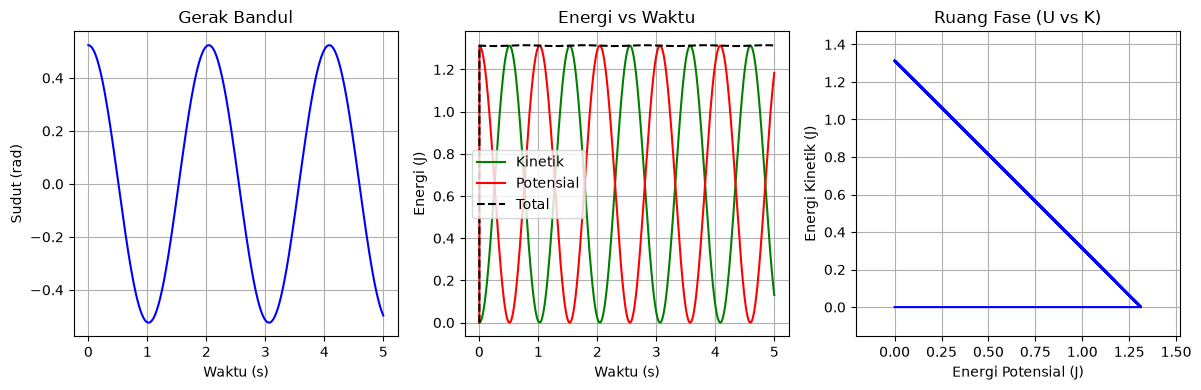

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
g = 9.8
L = 1.0                # panjang tali (m)
theta0 = np.radians(30) # sudut awal (rad)
omega0 = 0.0           # kecepatan sudut awal

# Simulasi numerik (pendekatan Euler)
dt = 0.001
t_total = 5.0
n_steps = int(t_total / dt)

t = np.zeros(n_steps)
theta = np.zeros(n_steps)
omega = np.zeros(n_steps)
K = np.zeros(n_steps)
U = np.zeros(n_steps)
E = np.zeros(n_steps)

theta[0] = theta0
omega[0] = omega0

for i in range(n_steps - 1):
    # Persamaan gerak bandul: alpha = -(g/L) * sin(theta)
    alpha = -(g / L) * np.sin(theta[i])
    omega[i+1] = omega[i] + alpha * dt
    theta[i+1] = theta[i] + omega[i+1] * dt
    t[i+1] = t[i] + dt
    
    # Energi (massa dianggap 1 kg)
    h = L * (1 - np.cos(theta[i+1]))  # ketinggian dari titik terendah
    U[i+1] = g * h
    K[i+1] = 0.5 * (L * omega[i+1])**2
    E[i+1] = K[i+1] + U[i+1]

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t, theta, 'b-')
plt.xlabel('Waktu (s)'); plt.ylabel('Sudut (rad)')
plt.title('Gerak Bandul')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t, K, 'g-', label='Kinetik')
plt.plot(t, U, 'r-', label='Potensial')
plt.plot(t, E, 'k--', label='Total')
plt.xlabel('Waktu (s)'); plt.ylabel('Energi (J)')
plt.title('Energi vs Waktu')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(U, K, 'b-')
plt.xlabel('Energi Potensial (J)')
plt.ylabel('Energi Kinetik (J)')
plt.title('Ruang Fase (U vs K)')
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()